# Project Instructions From Tutors

#### KEEPING IT AS IS FOR REFERENCE

## CAMELS Multifield Dataset

In this project we will analyse simulated datasets from the Cosmology and Astrophysics with MachinE Learning Simulations (CAMELS) Multifield Dataset, CMD, to attempt to determine the fundamental parameters of the universe.

The CAMELS CMD simualted dataset is enormous so in this project we will only be using one small corner of the simulated data. 

More details on the overall [CAMELS Multifield Dataset in their paper on arxiv](https://arxiv.org/abs/2109.10915).


## Cosmological parameters

Each map in the dataset comes from a simulation which is controlled by six parameters. Two of these are interesting cosmological parameters that we want to determine, whilst the other four parameters are effective parameters that we are less interested in but might need to consider to determine the interesting cosmological parameters.

| Variable      | Description |
| ----------- | ----------- |
| $\Omega_m$      | This is a cosmological parameter that represents the fraction of matter in the Universe.   |
| $\sigma_8$      | This is a cosmological parameter that controls the smoothness of the distribution of matter in the Universe  |
| $A_{SN1}$ & $A_{SN2}$     | These are two astrophysical parameters that controls two properties of supernova feedback  |
| $A_{AGN1}$ & $A_{AGN2}$     | These are two astrophysical parameters that control two properties of black-hole feedback|

## Types of 2D-Map

The simulated datasets are for a large number of astrophysical fields including
 
| Field   | Prefix   |
| ----------- | ---- | 
| Gas density     | Mgas |
| Gas velocity    | Vgas | 
| Gas temperature | T |
| Gas metallicity    | Z | 
| Neutral hydrogen density    | HI | 
| Electron number density    | ne | 
| Magnetic fields   | B | 
| Magnesium over Iron   | MgFe | 
| Dark matter density  | Mcdm | 
| Dark matter velocity  | Vcdm | 
| Stellar mass density | Mstar |  
| Total matter density | Mtot | 

There are several different types of datasets avalible deriving from different simulations and with different ways of varying the astrophysical parameters. In this miniproject we will confine ourselves to look only at the IllustrisTNG simulation where a single astrophysical parameter is varied at a time.

## Machine learning tasks

1. Train a machine learning algorithm to predict the cosmological parameters from a single map
2. Train a machine learning algorithm to predict the cosmological parameters from multiple maps (e.g. of different fields at the same time)

## Potential extensions

1. Train a machine learning algortithm on one field and use it to predict the cosmological parameters on other fields
2. Train a generative algorithm that is able to take a map of one field and produce a map of another, are there particular fields that are good or bad at predicting other fields?

## Things to remember
In the '1P' dataset that we have downloaded a single parameter is varied at a time. For each set of parameters there are 15 images. So 66 parameter combinations result in 990 images of each field.

Questions:
* What type of data preprocessing will be needed?
* How will you split the data in to train, validation and test samples?



## START OF NOTEBOOK

In [1]:
# numpy and math
import numpy as np
import math
from tensorflow import keras
# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, Model

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, GridSearchCV
from scikeras.wrappers import KerasRegressor, KerasClassifier

# Scipy
from scipy.stats import randint, uniform

# Plotting
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl
from matplotlib.colors import LogNorm

# Other
import pandas as pd
import os
import time
from itertools import product
import gc


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\makan\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\makan\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\makan\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\makan\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

In [2]:
if os.path.exists('model_comparison.csv'):
    os.remove('model_comparison.csv')
    print("Old CSV removed. Starting fresh.")

# Whats Happening in this Notebook


In this notebook, I conduct Exploratory Data Analysis to fully understand my data, and models


Then I train, test and hypertune on the B field to get a representative architecture to be applied to all fields as a base model

Base paper citation



# Why am I using B-field for hypertuning and initial training?

Navarro https://arxiv.org/pdf/2109.09747v1 showed that the B field had a middle of the pack perfomance so it should be representative for the other fields



From Fig. 3 and Fig. 2 in the paper

| Rank | Field | ⟨δΩm/Ωm⟩ |
|------|-------|-----------|
| 1 | Mdm | 2.9% |
| 2 | Mtot | 3.4% |
| 3 | HI | 4.2% |
| 4 | Mgas | 4.4% |
| 5 | ne | 5.0% |
| 6 | P | 5.3% |
| 6 | T | 5.3% |
| 8 | Vgas | 5.7% |
| **9** | **B** | **6.4%** |
| 10 | Vdm | 6.8% |
| 11 | Z | 8.8% |
| 12 | Mg/Fe | 11.4% |
| 13 | M★ | 19.8% |

B sits at **9th out of 13** for Ωm so its solidly middle-to-lower-middle. For σ8 it performs slightly better relatively (4.0%), but still comfortably mid-table.

So my thinking is that it's a genuinely representative field that experiences meaningful but not extreme astrophysical contamination, which makes hypertuning results on it informative for the general case.

Ideally, I would have hypertuned all the fields independently


# Loading Data

In [4]:
data_folder = r"C:\Users\makan\ML Y3 PHYSICS\camels project\camels\MAPS" # my data folder
params_path = os.path.join(data_folder, 'params_1P_IllustrisTNG.txt') # my params path
bmap_path  = os.path.join(data_folder, 'Maps_B_IllustrisTNG_1P_z=0.00.npy') # the B map

params = np.loadtxt(params_path) # paramters array, 66,6
bMap = np.load(bmap_path) # B maps

Trying to see my data structure

params.shape (66, 6)
bMap.shape (990, 256, 256)
Maps per paramater line 15
Maxiumum Value 2.011384e-06
Minimum Value 1.8111102e-15


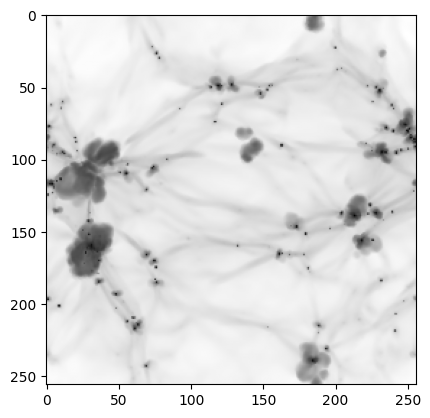

In [5]:

print("params.shape",params.shape)
print("bMap.shape",bMap.shape)
print("Maps per paramater line",bMap.shape[0]//params.shape[0])
print("Maxiumum Value",np.max(bMap[0]))
print("Minimum Value",np.min(bMap[0]))
fig, ax = plt.subplots()
ax.imshow(np.log10(bMap[0]),cmap="binary") # one of the bmaps 

## MY UNDERSTANDING

#### Understanding the Problem from a Statistical Mechanics Standpoint (my favourite Y2 module)


Macrostate - microstates with the same property

So in this case I have : 

**15 Microstates**(15 images sharing the same parameters) for **1 macrostate** (specific parameter combination)


So essentially the macrostate is the 6 parameters, **all 15 images share the same 6 parameters** but are just different in arrangement

Its a bit like: 3,3 4,2 and 1, 5 are all microstates of sum 6 but in different ways 
    
    
Each parameter has 11 different values

So in total, **66 total unique combinations of the parameters**

Leading to 990 images per field (we have 13 fields in total)

## The goal

Predicting the  6 parameters (macrostate), inferring from just one 1 image(microstate)

Ie it should predict the same parameters regardless of which of the 15 (microstate) images I show it from that unique parameter combination(macrostate). 

Just like in statistical mechanics, I'm trying to infer the macroscopic properties from microscopic snapshots. 

### Key points on the 15 images

Different random initial conditions (different seeds)

But evolved under the same physical laws (same parameters)

So they represent the cosmic variance - the natural variation I'd expect from different patches of the universe that share the same fundamental parameters

So again, the model needs to learn the underlying unique parameter combination (macrostate)  despite the image (microstate) variations

### Dataset structure 



In [6]:
np.shape(params)

(66, 6)

1 row is a unique combination of 6 parameters(so each row is a macrostate), and we have 66 rows

These are my labels


The actual data are the images accompanying the parameters

Each row is associated with 15 images...(I cannot forget this)

In [7]:
np.shape(bMap)

(990, 256, 256)

990 - all the different images in one field from 66 unique parameter combinations (macrostates) * 15 images per parameter combination (microstates per macrostate)

256 * 256 - Image size, 256 pixels by 256 pixels 


## Data Preprocessing


1. Scaling - for neural network inputs, could do log or just normal normalisation


2. Splitting - cannot be randomised as the test data should be unseen parameter combinations, so that the model actually learns

**So I should split by parameter combination(macrostate),so that the model can generalise to new, unseen parameter combinations.**

**All 15 images of a given param should stay together in either train, validation, or test.**

### Feedback - From Tutors on Understanding project

16 March 2026

Plot Gausssian - truth - predicted 

Trainable params vs mse plot - that would be great 

Fix one and change one at a time - grid search

Start simple and scale up

I shall implement this feedback where possible

## BASELINE ARCHITECTURE 

https://arxiv.org/pdf/2109.09747v1

### Multifield Cosmology with Artificial Intelligence

The paper above https://arxiv.org/pdf/2109.09747v1

Original CAMELS paper that applied CNNs to LH set in CAMELS dataset 

Key points

•	They used hydrodynamic simulations ie IllustrisTNG (SIMBA is also a hydrodynamic simulation but its not included in the paper they focused on TNG), the one that im using

•	They mainly focused on Gas temperature fields, though they analysed all 13 fields. Im starting with the magnetic and moving out

•	In terms of parameters, they evaluated all parameters but found best performance in Ω𝑚 and 𝜎8, and less accurate performance in AGNparameters (the astrophysical ones)

•	Their multi field analysis is good, will analyse when I get there. They did not explore cross field analysis


### Key Differences Between My Project and the Base Paper

The paper's model was designed for a much larger dataset (13,500 images) and a different task (predicting all six parameters, including astrophysical ones, with uncertainty). 

I am using a subset (1P dataset, 990 images) and only predicting two cosmological parameters. 

So scaling down will be necessary. 

### Why am I using this paper?


The idea is to adapt the paper's proven architecture to my smaller dataset (990 images) by scaling it down, but still retaining its core design principles (progressive downsampling, batch norm, LeakyReLU). 


Then systematically reduce capacity to find the sweet spot between underfitting and overfitting.


The paper's full model is overkill for my data, but its **architectural principles** (multi‑scale feature extraction, global pooling) are valuable. So, I have a small dataset but want to leverage a well‑designed architecture from the literature.


I will use their model architecture but start off from the simplest model I can find and then scale it up.  

Also, I will consider that my 1P dataset (single‑parameter variations) may be less informative than the LH set used in the paper.


## Achitectural Principles from Model Paper Adopted for Task


**1. Progressive downsampling** — What it does is gradually reduce spatial resolution in convolutional neural networks (CNNs) to capture higher-level features while reducing computation.

Found an Article on this https://ieeexplore.ieee.org/document/10208874
Blog on this https://visionbook.mit.edu/upsamplig_downsampling_2.html

Some information is obviously lost, but for helps with computation and reducing noise (capturing the global features)


**2. Batch Normalization (BatchNorm)** — What this does is normalise activations within a batch to stabilize and speed up training.

Proceedings of ML research article here https://proceedings.mlr.press/v37/ioffe15.html
Another blog https://machinelearningmastery.com/a-gentle-introduction-to-batch-normalization/

So basically it helps with regularisation and stabilisation

**3. LeakyReLU** — So its an activation function that allows a small gradient for negative inputs to avoid dead neurons.

Because some negatively biased neurons may fail to activate and 'die', read it in this blog https://medium.com/@sreeku.ralla/activation-functions-relu-vs-leaky-relu-b8272dc0b1be

A proper paper https://link.springer.com/chapter/10.1007/978-3-031-88279-1_10

They discussed the applications of LeakyReLU to Convolutional Neural Networks

## Objective

**In this notebook I start with a smallest possible model i can think of using this template and systematically increase capacity until performance saturates.**


In [8]:
# checking my params

for i in range(6):
    print(f"Column {i}: min={params[:,i].min():.3f}, max={params[:,i].max():.3f}")

Column 0: min=0.100, max=0.500
Column 1: min=0.600, max=1.000
Column 2: min=0.250, max=4.000
Column 3: min=0.250, max=4.000
Column 4: min=0.500, max=2.000
Column 5: min=0.500, max=2.000


From the CAMELS paper, they said

| Parameter | Range of Variation | Distribution |
|-----------|---------------------|--------------|
| Ωm        | 0.1 – 0.5           | uniform      |
| σ8        | 0.6 – 1.0           | uniform      |
| ASN1      | 0.25 – 4.0          | log uniform  |
| ASN2      | 0.5 – 2.0           | log uniform  |
| AAGN1     | 0.25 – 4.0          | log uniform  |
| AAGN2     | 0.5 – 2.0           | log uniform  |

*Note: "log uniform" means the parameter values are uniformly distributed in logarithmic space.*

So that confirms that Column 0 and 1 are Ωm and σ8 respectively 

**These are my target params for now.**

So I will simply take just the first two parameters. 

In [9]:
# Keeping only the first two cosmological parameters (Ωm, σ8)
params = params[:, :2]                                       # shape (66,2)

# Repeating each parameter row 15 times (one per image)
params_repeated = np.repeat(params, 15, axis=0)             # shape (990,2)

print(f"Total images: {bMap.shape[0]}, image size: {bMap.shape[1:]}")
print(f"Target shape: {params_repeated.shape}")

Total images: 990, image size: (256, 256)
Target shape: (990, 2)


### Preprocessing Images (log transform + normalization)


#### Why log transform?


Because, as Navarro noted, its a way to scale the data such that the magnititude of the contributions are equal. 

So log transforming, will do lots of things in my view :  reduce the impact of outliers, stabilises variance and makes the data more symmetrical so the CNN has an easier time learning


A blog on this https://www.clrn.org/why-log-transform-data/


A paper on this https://pmc.ncbi.nlm.nih.gov/articles/PMC9036143/ (non Ml but interesting still)


A statistical analysis paper on this https://www.sciencedirect.com/science/chapter/referencework/pii/B0080430767005131

In [10]:
# Log transform (adding small offset to avoid log(0))
X_log = np.log10(bMap + 1e-5)                               # shape (990,256,256)
X_log = X_log[..., np.newaxis]                               # add channel dim

# Splitting indices by macrostate (66 macrostates, 15 images each), as discussed

np.random.seed(42) # for reproducibility 

macro_indices = np.random.permutation(66)
train_macro = macro_indices[:53]   # 53 macrostates for training
val_macro   = macro_indices[53:60] # 7 macrostates for validation
test_macro  = macro_indices[60:]   # 6 macrostates for testing

In [11]:
# takes in a list of the parameters and return array of indices, I will use the indices to index the test and training sets
def macro_to_img_idx(macro_list):
    idx = []
    for m in macro_list:
        idx.extend(range(m*15, (m+1)*15))
    return np.array(idx)

train_idx = macro_to_img_idx(train_macro)
val_idx   = macro_to_img_idx(val_macro)
test_idx  = macro_to_img_idx(test_macro)

### CHECKING CLASS IMBALANCE

In [12]:
# Demonstrating class imbalance: group by actual (Ωm, σ8) values
train_params = params[train_macro]               # shape (53,2)
unique_pairs, pair_counts = np.unique(train_params, axis=0, return_counts=True)

print("Unique (Ωm, σ8) pairs in training set and their frequency:")
for (om, s8), cnt in zip(unique_pairs, pair_counts):
    print(f"Ωm={om:.2f}, σ8={s8:.2f} : {cnt} macrostate(s) -> {cnt*15} images")

Unique (Ωm, σ8) pairs in training set and their frequency:
Ωm=0.10, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.14, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.18, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.22, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.26, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=0.60 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=0.64 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=0.68 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=0.76 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=0.80 : 38 macrostate(s) -> 570 images
Ωm=0.30, σ8=0.84 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=0.92 : 1 macrostate(s) -> 15 images
Ωm=0.30, σ8=1.00 : 1 macrostate(s) -> 15 images
Ωm=0.34, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.42, σ8=0.80 : 1 macrostate(s) -> 15 images
Ωm=0.46, σ8=0.80 : 1 macrostate(s) -> 15 images


My traing has 53 macrostates total so

Ωm=0.30, σ8=0.80 : 38 macrostate(s) -> 570 images


is concerning...

Lets see it on a bar chart


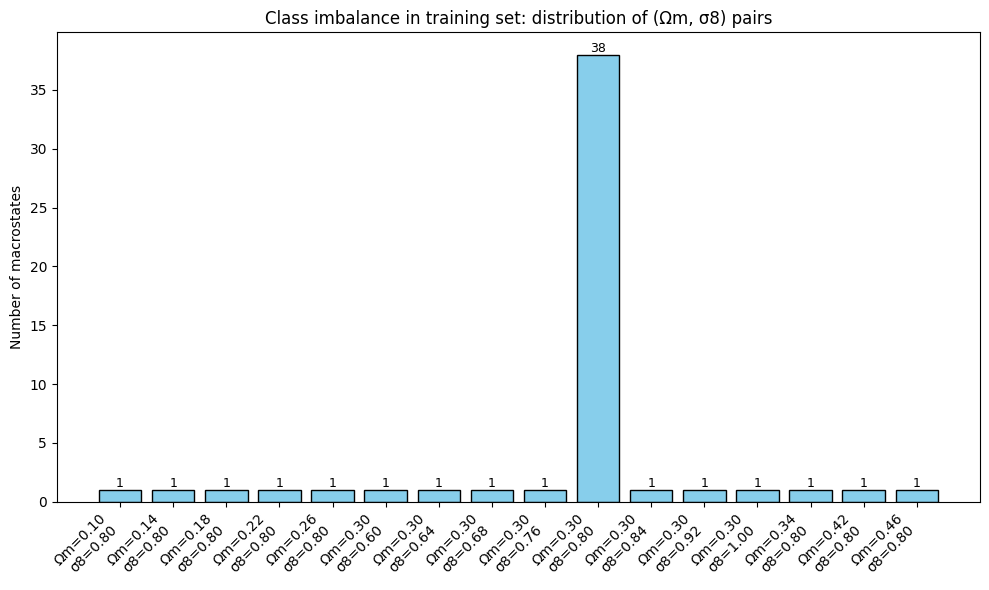

In [13]:
# Creating labels for each unique pair
labels = [f"Ωm={om:.2f}\nσ8={s8:.2f}" for (om, s8) in unique_pairs]

# Number of macrostates per pair (or number of images = pair_counts * 15)
macro_counts = pair_counts
image_counts = pair_counts * 15

# Choosing which to plot
counts = macro_counts   # or image_counts
ylabel = "Number of Macrostates"   # or "Number of images"

# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel(ylabel)
plt.title("Class imbalance in training set: distribution of (Ωm, σ8) pairs")

# Adding value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

It seems that the [0.3 0.8] parameter combination is overrepresented because it appears 38 times in diff macrostate combinations. 

Fundamentally, this is concerning because it shows class imbalance but also, I'm dealing with a 1P dataset so one parameter is varied and others are fixed, so this was bound to happen. 

These sets of 0.3, 0.8 are the sequences that vary ASN1, ASN2, AAGN1, and AAGN2, while keeping (Ωm, σ8) fixed at (0.3,0.8) and changing one astrophysical parameter at a time.

They are different macrostates BUT because im predicting only 2 params(the cosmological ones), if those are constant for 38 times what if the model learns to just predict them?

**This would not be an issue if i was predicting all of the 6 params, as all 53 macrostates are different if we look at all the 6 params, including the 38 macrostates with [0.3 0.8] for the 2 cosmological, because the other 4 values (astrophysical params) would be different**

But because im predicting **only the cosmological ones**, then  yes, I think its a class imbalance that needs addressing. 


To fix this I will use class weights so that the model doesnt just learn to predict the most common params. 

### ADDRESSING CLASS IMBALANCE

In [14]:
# Computing sample weights to correct for over‑represented (Ωm, σ8) combinations
unique_macros, counts = np.unique(train_macro, return_counts=True)
freq = counts / len(train_macro)                     # frequency of each macrostate
weight_per_macro = 1.0 / freq                         # inverse frequency
weight_per_macro = weight_per_macro / weight_per_macro.mean()   # normalise

# Mapping macrostate to weight and repeat for 15 images
groups_train = np.repeat(train_macro, 15)            # shape (795,)
sample_weights = np.array([weight_per_macro[np.where(unique_macros == m)[0][0]] 
                           for m in groups_train]).astype(np.float32)

### Normalising Images

Because neural networks converge faster when input features have zero mean and roughly unit variance (mean ≈0 and std ≈1), I use this cell to compute mean/std only from the training set only then normalise

Using only training to avoid validation and test sets influencing the training process


In [15]:
# Computing mean and std on training images only
X_train_log = X_log[train_idx]
mean = X_train_log.mean(axis=(0,1,2), keepdims=True) # mean
std  = X_train_log.std(axis=(0,1,2), keepdims=True) + 1e-8 # std

# Normalising all splits
X_train = (X_log[train_idx] - mean) / std # train
X_val   = (X_log[val_idx]   - mean) / std # validation
X_test  = (X_log[test_idx]  - mean) / std # test

print(f"Train images: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Train images: 795, Val: 105, Test: 90


### Scaling Targets



As shown above, the two output parameters that im trying to predict have different scales (Ωm ~ 0.1–0.5, σ8 ~ 0.6–1.0).

If I leave them unscaled, the loss (MSE) would be dominated by the parameter with larger variance,so scaling them to zero mean and unit variance makes them comparable, helping the network learn both equally.

In [16]:
# Scaling Targets (fitting on training only)
scaler = StandardScaler()
y_train_raw = params_repeated[train_idx]
scaler.fit(y_train_raw)

y_train = scaler.transform(y_train_raw)
y_val   = scaler.transform(params_repeated[val_idx])
y_test  = scaler.transform(params_repeated[test_idx])

print(f"Targets scaled: mean ~0, std ~1 for training set")


Targets scaled: mean ~0, std ~1 for training set


# All My Functions

In this section, I set all my functions to reduce as much repetition as possible



## 1. Building Model


### Model Architecture

Here, I use the architecture philosophy from Navarro, I set my  6 main blocks, final block, flatten then output

I motivated this ealier

It consists of **six convolutional blocks** that halve the spatial resolution each time, a **final convolutional block** that reduces the feature map to a single pixel, and a **fully‑connected head** that outputs the two cosmological parameters.

So each block follows the same pattern: `Conv2D` → `BatchNormalization` → `LeakyReLU`.

#### Architecture Summary - really self explanatory in the function

| Block | Layer Type | Output Shape | Filters |
|-------|------------|--------------|---------|
| Input | – | `(256, 256, 1)` | – |
| Block 1 | Conv2D (3×3, stride 2, same) | `(128, 128, base_filters)` | `base_filters` |
| Block 2 | Conv2D (3×3, stride 2, same) | `(64, 64, base_filters×2)` | `base_filters×2` |
| Block 3 | Conv2D (3×3, stride 2, same) | `(32, 32, base_filters×4)` | `base_filters×4` |
| Block 4 | Conv2D (3×3, stride 2, same) | `(16, 16, base_filters×8)` | `base_filters×8` |
| Block 5 | Conv2D (3×3, stride 2, same) | `(8, 8, base_filters×16)` | `base_filters×16` |
| Block 6 | Conv2D (3×3, stride 2, same) | `(4, 4, base_filters×32)` | `base_filters×32` |
| Final Conv | Conv2D (4×4, stride 1, valid) | `(1, 1, base_filters×64)` | `base_filters×64` |
| Flatten | – | `base_filters×64` | – |
| Dense | Dense + ReLU | `dense_units` | – |
| Dropout | Dropout | `dense_units` | – |
| Output | Dense (linear) | `num_outputs` (2) | – |


so the **fully‑connected head** (`Dense` + `Dropout`) performs the final regression to Ωm and σ8.

#### Tunable Hyperparameters that I have 

| Parameter | Role |
|-----------|------|
| `base_filters` | Controls the width of the convolutional backbone; starts at this value and doubles each block. |
| `dense_units` | Number of neurons in the penultimate dense layer. |
| `dropout` | Fraction of dense‑layer units dropped during training. |
| `num_outputs` | Fixed to 2 for Ωm and σ8. |



Insert metrics eqns here

In [17]:
def build_camels_cnn(input_shape, num_outputs, base_filters, dense_units, dropout):
    """
    Building a configurable CNN based on the CAMELS architecture.
    
    Parameters:
        input_shape (tuple): Shape of input images (height, width, channels), for multi I will set this to 12(next notebook)
        num_outputs (int): Number of regression targets (2 for Ωm, σ8), 
        base_filters (int): Number of filters in the first conv block (doubles each block)
        dense_units (int): Number of neurons in the fully-connected layer
        dropout (float): Dropout rate for regularization
    
    Returns:
        model (keras.Model): Compiled or uncompiled Keras model
        param_desc (dict): Dictionary of hyperparameters for logging
    """
    
    # Defining the input layer with the specified shape
    inputs = keras.Input(shape=input_shape)
    x = inputs
    
    # Block 1: 256 -> 128
    # Applying first convolutional layer with base_filters
    x = keras.layers.Conv2D(base_filters, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)          # Normalising activations
    x = keras.layers.LeakyReLU(alpha=0.2)(x)          # Applying LeakyReLU activation
    
    # Block 2: 128 -> 64
    # Doubling the number of filters
    x = keras.layers.Conv2D(base_filters*2, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 3: 64 -> 32
    # Im doubling filters, again
    x = keras.layers.Conv2D(base_filters*4, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 4: 32 -> 16
    # Continuing progressive downsampling
    x = keras.layers.Conv2D(base_filters*8, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 5: 16 -> 8
    x = keras.layers.Conv2D(base_filters*16, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Block 6: 8 -> 4
    x = keras.layers.Conv2D(base_filters*32, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Final block: 4 -> 1 (kernel size = 4, valid padding)
    # Reducing spatial dimensions to 1x1 using a 4x4 kernel
    x = keras.layers.Conv2D(base_filters*64, 4, strides=1, padding='valid')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.2)(x)
    
    # Flattening the (1, 1, base_filters*64) tensor into a 1D vector
    x = keras.layers.Flatten()(x)
    
    # Adding a dense (fully-connected) layer for final representation
    x = keras.layers.Dense(dense_units, activation='relu')(x)
    
    # Applying dropout for regularization
    x = keras.layers.Dropout(dropout)(x)
    
    # Output layer: predicting num_outputs values (linear activation for regression)
    outputs = keras.layers.Dense(num_outputs)(x)
    
    # Creating the Keras Model object
    model = keras.Model(inputs, outputs)
    
    # Capturing hyperparameters in a dictionary for logging and comparison
    param_desc = {
        'input_shape': input_shape,
        'num_outputs': num_outputs,
        'base_filters': base_filters,
        'dense_units': dense_units,
        'dropout': dropout
    }
    
    return model, param_desc

## 2. Training Model Function


Here, I define my `train_model` function, which handles compilation and training of a Keras model. 


It uses **Adam optimizer**, **mean squared error loss**, and **early stopping** to prevent overfitting. 


The function returns the training history which I will use for later analysis esp plotting loss curves. 

### Motivating My Loss Function

I use **mean squared error (MSE)** as the loss function during training. MSE penalises larger deviations more heavily than smaller ones, which I think is desirable for cosmological parameter estimation because outliers can significantly skew results.

Though obviously I will log scale AND normalise first to reduce that effect

The loss for $n$ samples is computed as:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad [9]
$$

where $y_i$ is the true parameter value and $\hat{y}_i$ is the predicted value. This choice follows the standard regression approach used in the CAMELS literature [9].

An article that I found on this https://pmc.ncbi.nlm.nih.gov/articles/PMC8279135/

In this article they compared different loss functions like R-squared, SMAPE, MAE, MAPE, MSE and RMSE 


I went with MSE for the reason above, though they noted that R-squared is likely better in some scenarios. Less relevant because they are regression tasks yes but for medical problems...im dealing with cosmology here

In [18]:
def train_model(model, X_train, y_train, X_val, y_val,
                lr=1e-3, patience=8, epochs=50, batch_size=10, verbose=1,  sample_weight=None):
    """
    Compiling and training a Keras model with early stopping.
    
    Parameters:
        model: Keras Model instance (already built)
        X_train, y_train: Training data and targets (scaled)
        X_val, y_val: Validation data and targets (scaled)
        lr (float): Learning rate for Adam optimizer
        patience (int): Number of epochs to wait before early stopping
        epochs (int): Maximum number of training epochs
        batch_size (int): Batch size for training
        verbose (int): Verbosity level (0, 1, or 2)
        sample_weight (array): Sample weights for training class imbalance
    
    Returns:
        history: Keras History object containing loss and metric values
    """
    
    # Compiling the model with Adam optimizer and MSE loss (suitable for regression)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='mse',                  # Mean Squared Error loss
                  metrics=['mae'])             # Monitoring Mean Absolute Error
    
    # Setting up early stopping callback to halt training when validation loss stops improving
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',                    # Watching validation loss
        patience=patience,                     # Waiting this many epochs before stopping
        restore_best_weights=True              # Restoring weights from the best epoch
    )
    
    # Fitting the model to the training data
    history = model.fit(
        X_train, y_train,                      # Training data
        validation_data=(X_val, y_val),        # Validation data for monitoring
        epochs=epochs,                         # Maximum number of epochs to run
        batch_size=batch_size,                 # Number of samples per gradient update
        callbacks=[early_stop],                # Including early stopping
        verbose=verbose,                       # Controlling output verbosity
        sample_weight=sample_weight            # Applying sample weights if provided
    )
    
    # Returning the training history for later analysis (e.g., loss curves, metrics)
    return history

## 3. Get predictions function

In [19]:
def get_predictions(model, X_test, scaler, y_test):
    """
    Generating predictions and also (very important) inverse transform to original units.
    
    Returns:
        y_true: true values in original units
        y_pred: predicted values in original units
    """
    y_pred_scaled = model.predict(X_test, verbose=1)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)
    return y_true, y_pred

## 4. Saving Results Functions



Here, in the next 2 cells I am defining two functions for model evaluation AND record‑keeping.  

- **`regression_report`** – This just computes a standard set of regression metrics (MAE, MAPE, RMSE, R², and Pearson correlation) for each target parameter, printing them to the console for immediate inspection and returning them as a dictionary.  I am motivating why I took these params below

- **`save_model_results`** – So this takes my trained model, together with its training history, test data, and hyperparameter description, then (i) generates predictions in physical units, (ii) calculates all metrics using `regression_report`, and (iii) then appends the results—along with metadata such as the number of trainable parameters and a timestamp—to a CSV file. 


So that I can systematically compare different architectures and hyperparameter choices later.

### Why am I monitoring MAE, MAPE, RMSE, R2 AND Pearson Correlation for Test Perfomance

Because I dont want to be 'blind', Im skeptical of assessing perfomance on just one metric

In the report, I may use one as the final (probably MAPE because its easily interpretable but a whole suite of metrics helps as they all complement each other.

For example, whats good about 2% MAPE if r is around 0.2? It can be very misleading, I reckon I will see this later on


Also, I didnt use **MSE** ( used as the training loss),because it is not directly interpretable in physical units. 

- **MAPE (Mean Absolute Percentage Error)** – My primary test metric because it is **scale‑independent**, allowing fair comparison across different fields and parameters (Equation 3).
- **MAE (Mean Absolute Error)** – Tracks average absolute deviation in the original units; it mirrors the `mae` metric monitored during training (Equation 2).
- **RMSE (Root Mean Squared Error)** – Penalises large errors more heavily than MAE, highlighting the presence of outliers (Equation 5).
- **Pearson correlation (r)** – Measures the linear relationship between predictions and true values. A low correlation can flag models that predict near the mean but fail to capture the underlying trend.
- **R² (Coefficient of Determination)** – Indicates the proportion of variance explained by the model. A negative R² signals that the model is performing worse than simply predicting the mean of the training data.



4.a regression report function

In [20]:
def regression_report(y_true, y_pred, param_names=['Ωm', 'σ8']):
    """Printing and returning dictionary of metrics."""
    results = {}
    # Iterating over each parameter (for now its Ωm, σ8)
    for i, name in enumerate(param_names):
        # Computing Mean Absolute Error (average absolute difference)
        mae = np.mean(np.abs(y_pred[:, i] - y_true[:, i]))
        # Computing Mean Absolute Percentage Error (as a percentage)
        mape = np.mean(np.abs((y_pred[:, i] - y_true[:, i]) / y_true[:, i])) * 100
        # Computing Root Mean Squared Error (square root of average squared difference)
        rmse = np.sqrt(np.mean((y_pred[:, i] - y_true[:, i])**2))
        # Computing R² score (coefficient of determination)
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        # Computing Pearson correlation coefficient (extracting [0,1] element from correlation matrix)
        corr = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
        
        # Storing with parameter prefix, for reference, would be useless without
        results[f'{name}_MAE'] = mae
        results[f'{name}_MAPE'] = mape
        results[f'{name}_RMSE'] = rmse
        results[f'{name}_R2'] = r2
        results[f'{name}_corr'] = corr
        
        # Keeping the print for immediate feedback, so that I see whats going on
        print(f"{name}: MAE={mae:.3f}, MAPE={mape:.1f}%, RMSE={rmse:.3f}, R²={r2:.3f}, r={corr:.3f}")
    # Returning the populated results dictionary
    return results

4.b, save model results function

In [21]:
def save_model_results(model, history, X_test, y_test, scaler, 
                       model_name, param_desc, 
                       csv_file='model_comparison.csv'):
    """
    model: trained Keras model
    history: History object from model.fit()
    X_test, y_test: test data (scaled)
    scaler: used to inverse transform y_test and predictions
    model_name: string identifier for architecture
    param_desc: dictionary with hyperparameters 
    csv_file: path to CSV file to append results
    """
    # Get predictions in original units
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)
    
    # Compute metrics using the updated regression_report
    metrics = regression_report(y_true, y_pred, param_names=['Ωm', 'σ8'])
    
    # Add training and validation losses (best epoch)
    if history is not None:
        metrics['train_loss_best'] = min(history.history['loss'])
        metrics['val_loss_best'] = min(history.history['val_loss'])
        # Adding final losses
        metrics['train_loss_final'] = history.history['loss'][-1]
        metrics['val_loss_final'] = history.history['val_loss'][-1]
    
    # Adding metadata
    metrics['model_name'] = model_name
    metrics['params_total'] = model.count_params()
    metrics['timestamp'] = time.strftime('%Y-%m-%d %H:%M:%S')
    # Adding all hyperparameters from param_desc
    for key, value in param_desc.items():
        metrics[key] = value
    
    # Converting to DataFrame and appending to CSV
    df_new = pd.DataFrame([metrics])
    if not os.path.isfile(csv_file):
        df_new.to_csv(csv_file, index=False)
    else:
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    print(f"Results saved to {csv_file}")

## 5. Plot Predictions Function

Self explanatory, i am plotting predictions

In [22]:
def plot_predictions(y_true, y_pred, model_name="", param_names=['Ωm', 'σ8'], save_path=None):
    """
    Creating scatter plots of true vs predicted values for each parameter.
    
    Args:
        y_true: true values in original units
        y_pred: predicted values in original units
        model_name: string to include in title 
        param_names: list of parameter names
        save_path: saving figure to this path
    """
    # Computing MAE for each parameter (axis=0 aggregates over samples)
    mae_phys = np.mean(np.abs(y_pred - y_true), axis=0)
    
    # Creating subplots for each parameter (side-by-side)
    fig, axes = plt.subplots(1, len(param_names), figsize=(10, 4))
    if len(param_names) == 1:
        axes = [axes]  # Making iterable if only one subplot
    
    # Iterating over each parameter to generate its scatter plot
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        # Plotting true vs predicted values with transparency for overlapping points
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.6)
        
        # Determining the range for the diagonal reference line
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        # Drawing the diagonal (perfect prediction) line
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
        
        # Labeling axes and building title string
        ax.set_xlabel(f'True {name}')
        ax.set_ylabel(f'Predicted {name}')
        title = f'{name}'
        if model_name:
            title = f'{model_name}: {title}'
        # Appending MAE value to the title for reference
        title += f'\nMAE = {mae_phys[i]:.3f}'
        ax.set_title(title)
    
    # Adjusting layout to prevent overlap
    plt.tight_layout()
    # Saving figure
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    # Displaying the plot
    plt.show()

## 6. Plotting Loss Curves

Self explanatory, plotting loss curves for reference later

Will be looking out for overfitting(where the training loss improves but val balloons) and underfitting where training loss barely improves and val is kinda static 

Also adding red dot for best epoch

In [23]:
def plot_loss_curves(history, model_name="", save_path=None):
    """
    Plot training and validation loss curves from a Keras history object.
    
    Args:
        history: History object from model.fit()
        model_name: string to include in title (e.g., '40M params')
        save_path: if provided, save figure to this path
    """
    # Creating a new figure with specified size
    plt.figure(figsize=(8, 5))
    
    # Plotting training and validation loss values over epochs
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    
    # Finding the epoch with the lowest validation loss (best epoch)
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])
    
    # Marking the best epoch with a red dot on the validation curve, makes it easier to see whats going on
    plt.scatter(best_epoch-1, best_val_loss, color='red', s=50, 
                label=f'Best val @ epoch {best_epoch}', zorder=5)
    
    # Setting plot title (including model name if provided)
    plt.title(f'{model_name} Loss Curve' if model_name else 'Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    # Adding a light grid for readability
    plt.grid(True, alpha=0.3)
    
    # Saving the figure to disk if a save path is specified
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    # Displaying the plot
    plt.show()

### BASE MODEL

Im starting  with 2 filters and 2 dense units, simplest model thats somewhat meaningful

In [50]:
# Building simplest model
simplest, param_desc_simplest = build_camels_cnn(
    input_shape=(256,256,1), # 1 channel, just my B maps for now
    num_outputs=2,
    base_filters=2, # 2 base filters
    dense_units=2, # 2 dense units
    dropout=0.5, 

)
simplest.summary() # model summary

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_21 (LeakyReLU)           │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_22 (LeakyReLU)           │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_23 (LeakyReLU)           │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_24 (LeakyReLU)           │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_25 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 157,176 (613.97 KB)

 Trainable params: 156,668 (611.98 KB)

 Non-trainable params: 508 (1.98 KB)

In [51]:
history_simplest = train_model(simplest, X_train, y_train, X_val, y_val,     sample_weight=sample_weights
) # training simplest model


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 5.2082 - mae: 1.1658 - val_loss: 1.4301 - val_mae: 0.4895
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.1659 - mae: 0.4862 - val_loss: 1.4259 - val_mae: 0.4930
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.0364 - mae: 0.4358 - val_loss: 1.4539 - val_mae: 0.5039
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.9508 - mae: 0.4102 - val_loss: 1.4252 - val_mae: 0.4972
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.9556 - mae: 0.4103 - val_loss: 1.4147 - val_mae: 0.4972
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.9896 - mae: 0.4288 - val_loss: 1.4083 - val_mae: 0.4989
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.0272 - mae: 0.4311 - val_loss: 1.3945 - val_mae: 0.5057
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.9136 - mae: 0.4024 - val_loss: 1.4051 - val_mae: 0.5041
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.86

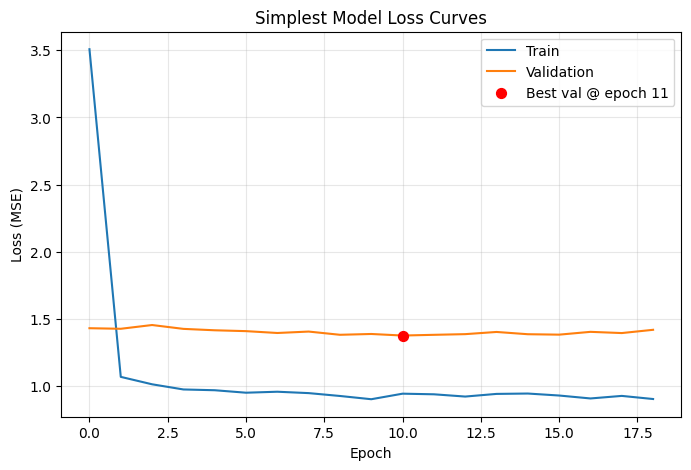

In [59]:
# Saving loss curves
plot_loss_curves(history_simplest, model_name="Simplest Model", save_path="loss_simplest.png")

#### Simplest model loss function commentary

Hmmmm, **validation loss never improved**

Train loss dropped once but plateaued. 


**This model is an underfit**

In [53]:
# After training, get predictions function
y_true, y_pred = get_predictions(simplest, X_test, scaler, y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step


In [60]:
# saving model results
save_model_results(simplest, history_simplest, X_test, y_test, scaler,
                   model_name="Simplest Model", param_desc=param_desc_simplest)

Ωm: MAE=0.018, MAPE=4.9%, RMSE=0.035, R²=-0.345, r=0.071
σ8: MAE=0.043, MAPE=5.0%, RMSE=0.073, R²=-0.027, r=0.335
Results saved to model_comparison.csv


#### UNDERFIT DISCUSSION

Low r, and negative rsquared.

Indicating low fit/underfit, though MAPE is excellent for such a small model. I think its misleading in this case, looking at the other parameters. 

Firstly, r is very low. So no correlation between the predictions and the true values. 

Rsquared is negative, meaning, the model cant explain most of the variation of the data. Its actually worse than a horizontal line fit...


**Which is why, my decision to report other metrics because MAPE does not tell the full story, checks out.** 

Lovely stuff, moving on

Plotting predictions

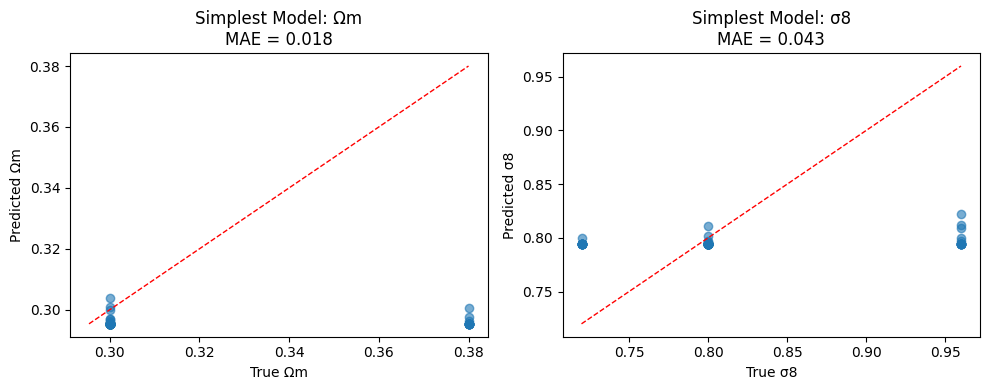

In [61]:
# Saving the predictions plot
plot_predictions(y_true, y_pred, model_name="Simplest Model", save_path="scatter_simplest.png")

In [57]:
# Evaluating On Test Set ( still in scaled space)
test_loss_simplest, test_mae_scaled_simplest = simplest.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_simplest:.4f}")



Test MAE (scaled): 0.6049


### **I'm doubling the capacity**

Across both dense units and base filters

In [62]:
# Building 630k model, double the capacity
model_630k, param_desc_630k = build_camels_cnn(
    input_shape=(256,256,1),
    num_outputs=2,
    base_filters=4, # 4 from 2
    dense_units=4,      # 4 from 2
    dropout=0.5
)
model_630k.summary()

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 128, 128, 4)         │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_35               │ (None, 128, 128, 4)         │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_35 (LeakyReLU)           │ (None, 128, 128, 4)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 64, 64, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_36               │ (None, 64, 64, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_36 (LeakyReLU)           │ (None, 64, 64, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 32, 32, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_37               │ (None, 32, 32, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_37 (LeakyReLU)           │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_38               │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_38 (LeakyReLU)           │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_39 (Conv2D)                   │ (None, 8, 8, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_39               │ (None, 8, 8, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_39 (LeakyReLU)           │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 626,110 (2.39 MB)

 Trainable params: 625,094 (2.38 MB)

 Non-trainable params: 1,016 (3.97 KB)

In [63]:
# Training 630k params model
history_630k = train_model(model_630k, X_train, y_train, X_val, y_val,   sample_weight=sample_weights)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 4.6387 - mae: 1.1789 - val_loss: 1.4445 - val_mae: 0.5056
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.9394 - mae: 0.4497 - val_loss: 1.4144 - val_mae: 0.5195
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.8589 - mae: 0.4352 - val_loss: 1.2688 - val_mae: 0.5183
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.8959 - mae: 0.4505 - val_loss: 1.4410 - val_mae: 0.5027
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.8545 - mae: 0.4061 - val_loss: 1.3525 - val_mae: 0.4747
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.7885 - mae: 0.3991 - val_loss: 1.3452 - val_mae: 0.4624
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.8561 - mae: 0.4003 - val_loss: 1.3244 - val_mae: 0.4539
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.8800 - mae: 0.3826 - val_loss: 1.3138 - val_mae: 0.4572
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.80

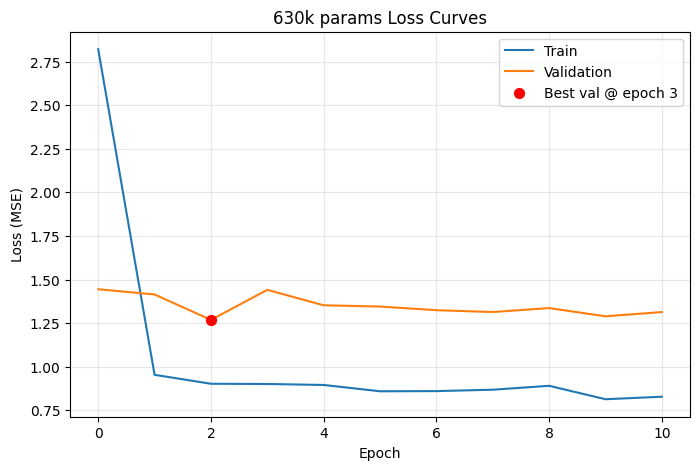

In [64]:
# Plotting loss curves
plot_loss_curves(history_630k, model_name="4 Base Filters 4 Dense Units Model (630k Parameters)", save_path="loss_630k.png")

##### 630k parameters model loss function commentary

The model is not a good fit, val loss barely improved, training dropped once and plateaued like before

Which is suspicious because the model is larger, id think it would capture more than the simple 2 base filters and dense units

In [65]:
# After training, get predictions function
y_true, y_pred = get_predictions(model_630k, X_test, scaler, y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step


In [66]:
# saving model results
save_model_results(model_630k, history_630k, X_test, y_test, scaler,
                   model_name="4 Base Filters 4 Dense Units Model", param_desc=param_desc_630k)

Ωm: MAE=0.022, MAPE=6.6%, RMSE=0.034, R²=-0.315, r=0.452
σ8: MAE=0.044, MAPE=5.1%, RMSE=0.074, R²=-0.071, r=0.081
Results saved to model_comparison.csv


**Worse perfomance, across most metrics than the simpler model, indicating that simply increasing capacity was probably misguided**

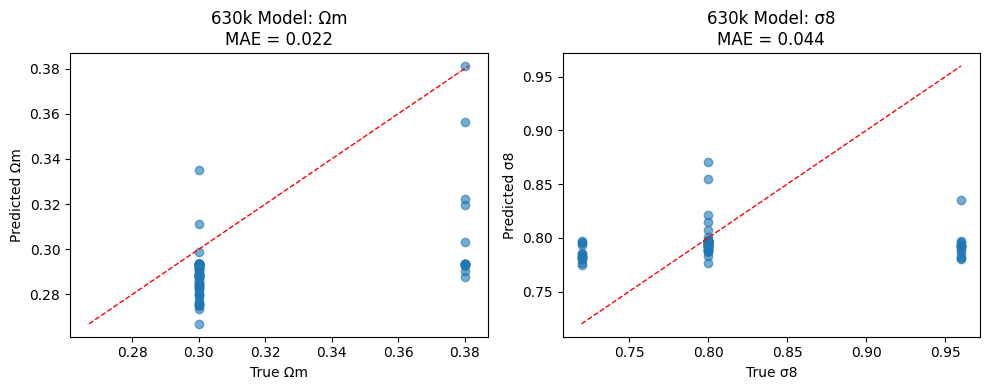

In [67]:
# Plotting predictions
plot_predictions(y_true, y_pred, model_name="4 Base Filters 4 Dense Units Model", save_path="scatter_630k.png")

In [68]:
# Evaluating On Test Set ( still in scaled space)
test_loss_630k, test_mae_scaled_630k= model_630k.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_630k:.4f}")



Test MAE (scaled): 0.6614


## Analysis of the Base Models

Initially I started with the simplest model which was 2 base filters and 2 dense units

When that underfit, I doubled both base filters and dense units. 


But that did not improve....


MAPE is now worse (MAE=0.022, MAPE=6.6%, σ8: MAE=0.044, MAPE=5.1% compared to m: MAE=0.018, MAPE=4.9%
σ8: MAE=0.043, MAPE=5.0%)


BUT correlation has improved for Ωm r=0.452 but dropped for σ8 r=0.081 relative to to Ωm:r=0.071 σ8: r=0.335



But, it highlights that perhaps I have reached the plateau, ie its no longer  **diminishing returns associated with the complex model** but actually a drop in perfomance




## IDEA - Keep base filters fixed

I can keep that fixed and vary dense units, and vice versa. 

Because right now, by varying both, im just doing glorified guesswork. 


So the idea is 

To systematically find the minimal sufficient model, I will fix base_filters at its smallest meaningful value which is (2) and then increase dense_units stepwise.


This then isolates the effect of the head capacity, making it clear **when the model stops underfitting**. 


Once I find the smallest dense_units that works well, I can increase base_filters to see if more convolutional capacity further improves performance. 

### 2 base filters and 10 Dense units


In [70]:
# 2 base filters and 10 Dense units model
model_10_dense, param_desc_10_dense = build_camels_cnn(
    input_shape=(256,256,1),
    num_outputs=2,
    base_filters=2, # im keeping this constant
    dense_units=10,      # 10 from 2
    dropout=0.5
)
model_10_dense.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_49               │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_49 (LeakyReLU)           │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_50 (Conv2D)                   │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_50               │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_50 (LeakyReLU)           │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_51 (Conv2D)                   │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_51               │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_51 (LeakyReLU)           │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_52 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_52               │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_52 (LeakyReLU)           │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_53 (Conv2D)                   │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_53               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_53 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_54 (Conv2D)                   │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_54               │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 158,224 (618.06 KB)

 Trainable params: 157,716 (616.08 KB)

 Non-trainable params: 508 (1.98 KB)

In [71]:
# Training 2 base filters and 10 Dense units model
history_10_dense = train_model(model_10_dense, X_train, y_train, X_val, y_val,sample_weight=sample_weights)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 1.9876 - mae: 0.8383 - val_loss: 1.6151 - val_mae: 0.5898
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.9997 - mae: 0.4632 - val_loss: 1.6968 - val_mae: 0.6381
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.9208 - mae: 0.4264 - val_loss: 1.4444 - val_mae: 0.5057
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.9118 - mae: 0.4346 - val_loss: 1.3867 - val_mae: 0.5089
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.7382 - mae: 0.3757 - val_loss: 1.2019 - val_mae: 0.4720
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.7295 - mae: 0.3825 - val_loss: 1.0878 - val_mae: 0.4495
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.6042 - mae: 0.3390 - val_loss: 1.0497 - val_mae: 0.4430
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.6341 - mae: 0.3487 - val_loss: 1.1271 - val_mae: 0.4798
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.71

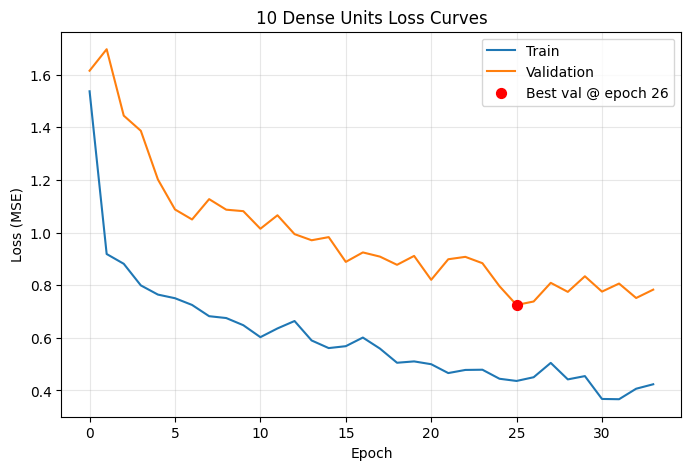

In [72]:
# Plotting 2 base filters and 10 Dense units model loss
plot_loss_curves(history_10_dense, model_name="10 Dense Units 2 Base Filters", save_path="loss_10_dense.png")

Now Im getting somewhere, training loss is improving, and validation loss as well. 

In [73]:
# After training, get predictions function
y_true, y_pred = get_predictions(model_10_dense, X_test, scaler, y_test)


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021DF7B759E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step


In [74]:
# Saving model results
save_model_results(model_10_dense, history_10_dense, X_test, y_test, scaler,
                   model_name="10 Dense Units 2 Base Filters", param_desc=param_desc_10_dense)

Ωm: MAE=0.017, MAPE=5.1%, RMSE=0.027, R²=0.160, r=0.542
σ8: MAE=0.034, MAPE=4.0%, RMSE=0.059, R²=0.336, r=0.689
Results saved to model_comparison.csv


Better results, low MAPE AND increased correlation, and also, non negative R squared

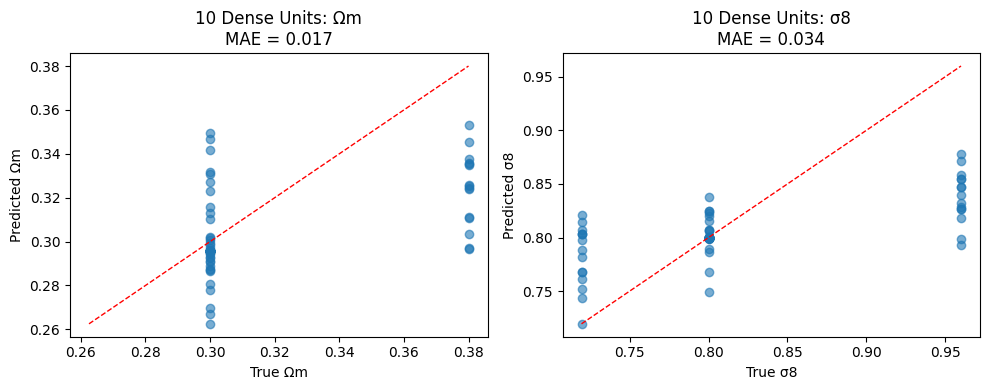

In [75]:
# Plotting predictions on a scatter plot

plot_predictions(y_true, y_pred, model_name="10 Dense Units 2 Base Filters", save_path="scatter_10_dense.png")

In [76]:
# Evaluating On Test Set ( still in scaled space)
test_loss_10_dense, test_mae_scaled_10_dense= model_10_dense.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_10_dense:.4f}")



Test MAE (scaled): 0.5089


### 15 Dense Units and 2 Base Filters

In [77]:
# 15 Dense Units and 2 Base Filters
model_15_dense, param_desc_15_dense = build_camels_cnn(
    input_shape=(256,256,1),
    num_outputs=2,
    base_filters=2, # im keeping this constant
    dense_units=15,      # 15 from 10
    dropout=0.5
)
model_15_dense.summary()

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_56               │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_56 (LeakyReLU)           │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_57 (Conv2D)                   │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_57               │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_57 (LeakyReLU)           │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_58 (Conv2D)                   │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_58               │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_58 (LeakyReLU)           │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_59 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_59               │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_59 (LeakyReLU)           │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_60 (Conv2D)                   │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_60               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_60 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_61               │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 158,879 (620.62 KB)

 Trainable params: 158,371 (618.64 KB)

 Non-trainable params: 508 (1.98 KB)

In [78]:
# Training 15 Dense Units and 2 Base Filters Model
history_15_dense = train_model(model_15_dense, X_train, y_train, X_val, y_val,sample_weight=sample_weights)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 2.8139 - mae: 1.1806 - val_loss: 1.5046 - val_mae: 0.5769
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.8112 - mae: 0.5001 - val_loss: 1.3943 - val_mae: 0.5396
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.6854 - mae: 0.4157 - val_loss: 1.1200 - val_mae: 0.4774
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.7431 - mae: 0.4673 - val_loss: 1.0501 - val_mae: 0.4849
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.7126 - mae: 0.4366 - val_loss: 0.9908 - val_mae: 0.4574
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.5584 - mae: 0.3500 - val_loss: 1.0163 - val_mae: 0.4388
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5485 - mae: 0.3557 - val_loss: 0.8891 - val_mae: 0.4355
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5342 - mae: 0.3497 - val_loss: 0.8091 - val_mae: 0.4299
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.40

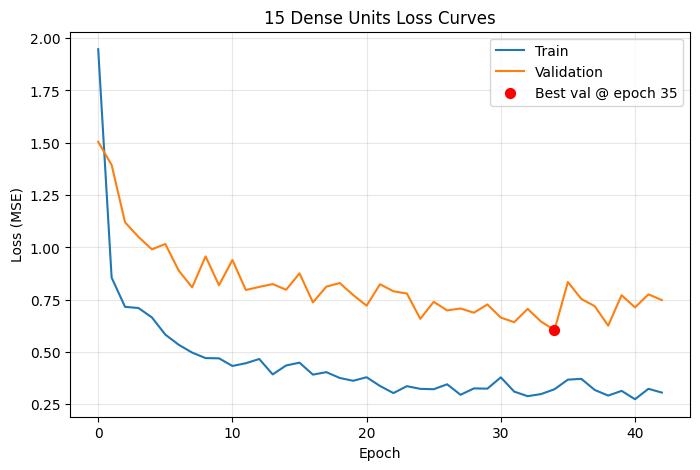

In [79]:
# Plotting loss curves
plot_loss_curves(history_15_dense, model_name="15 Dense Units 2 Base Filters", save_path="loss_15_dense.png")

No sign of overfitting just yet (id look out for balloning val loss but dropping training loss)

In [80]:
# After training, get predictions function
y_true, y_pred = get_predictions(model_15_dense, X_test, scaler, y_test)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/stepWARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021E2EB0C2C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step


In [81]:
# saving model results
save_model_results(model_15_dense, history_15_dense, X_test, y_test, scaler,
                   model_name="15 Dense Units 2 Base Filters Model", param_desc=param_desc_15_dense)


Ωm: MAE=0.013, MAPE=4.0%, RMSE=0.025, R²=0.299, r=0.601
σ8: MAE=0.027, MAPE=3.2%, RMSE=0.048, R²=0.547, r=0.832
Results saved to model_comparison.csv


Both MAPE  and corelation have improved,Perfomance seems to be still improving, no sign of hitting the ceiling just yet

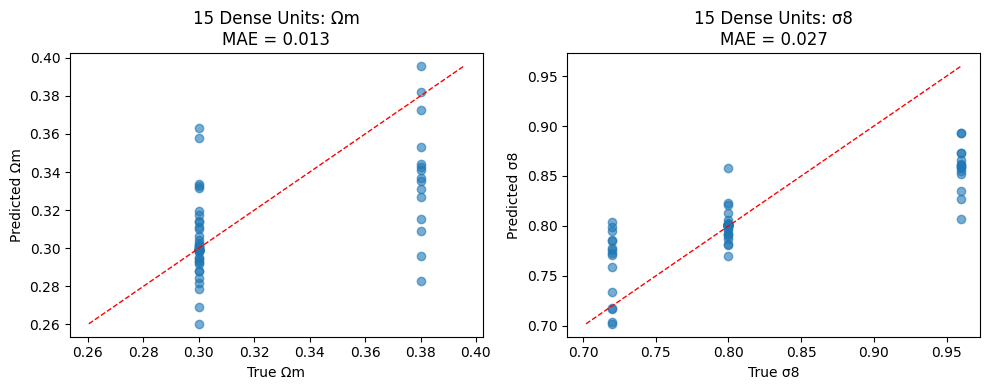

In [82]:
# Plotting predictions on a scatter plot

plot_predictions(y_true, y_pred, model_name="15 Dense Units 2 Base Filters Model", save_path="scatter_15_dense.png")

In [83]:
# Evaluating On Test Set ( still in scaled space)
test_loss_15_dense, test_mae_scaled_15_dense= model_15_dense.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_15_dense:.4f}")



Test MAE (scaled): 0.4056


### 20 Dense Units and 2 Base Filters 

In [84]:
# 20 Dense Units and 2 Base Filters model
model_20_dense, param_desc_20_dense = build_camels_cnn(
    input_shape=(256,256,1),
    num_outputs=2,
    base_filters=2, # im keeping this constant
    dense_units=20,      # 20 from 15
    dropout=0.5
)
model_20_dense.summary()

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_63 (Conv2D)                   │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_63               │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_63 (LeakyReLU)           │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_64               │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_64 (LeakyReLU)           │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_65 (Conv2D)                   │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_65               │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_65 (LeakyReLU)           │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_66 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_66               │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_66 (LeakyReLU)           │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_67 (Conv2D)                   │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_67               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_67 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_68 (Conv2D)                   │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_68               │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 159,534 (623.18 KB)

 Trainable params: 159,026 (621.20 KB)

 Non-trainable params: 508 (1.98 KB)

In [85]:
# Training 20 Dense Units and 2 Base Filters model
history_20_dense = train_model(model_20_dense, X_train, y_train, X_val, y_val,sample_weight=sample_weights)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 2.4951 - mae: 1.1016 - val_loss: 1.7447 - val_mae: 0.6669
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.8064 - mae: 0.5124 - val_loss: 1.8755 - val_mae: 0.7424
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.7557 - mae: 0.4498 - val_loss: 1.4640 - val_mae: 0.5668
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5513 - mae: 0.3767 - val_loss: 1.3096 - val_mae: 0.5227
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5882 - mae: 0.3951 - val_loss: 1.1814 - val_mae: 0.5063
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.5605 - mae: 0.3492 - val_loss: 1.0468 - val_mae: 0.4503
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5569 - mae: 0.3720 - val_loss: 0.9953 - val_mae: 0.4388
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.5571 - mae: 0.3596 - val_loss: 0.8958 - val_mae: 0.4494
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.41

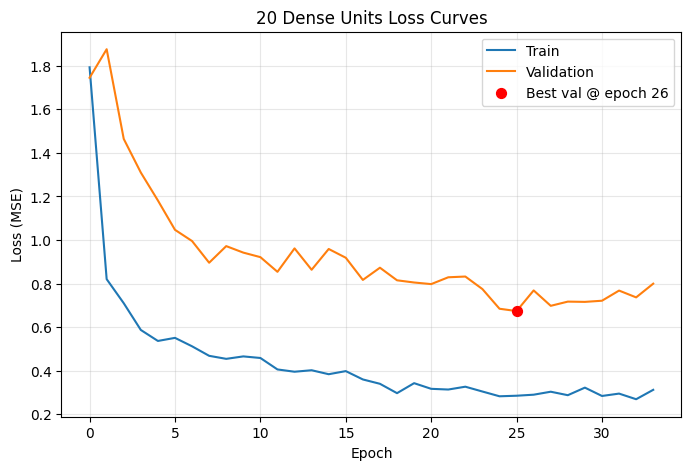

In [86]:
plot_loss_curves(history_20_dense, model_name="20 Dense Units 2 Base Filters Model", save_path="loss_20_dense.png")

In [87]:
# After training, get predictions function
y_true, y_pred = get_predictions(model_20_dense, X_test, scaler, y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step


In [88]:
# Saving Model results
save_model_results(model_20_dense, history_20_dense, X_test, y_test, scaler,
                   model_name="20 Dense Units 2 Base Filters Model", param_desc=param_desc_20_dense)


Ωm: MAE=0.013, MAPE=3.9%, RMSE=0.021, R²=0.481, r=0.699
σ8: MAE=0.031, MAPE=3.6%, RMSE=0.055, R²=0.417, r=0.739
Results saved to model_comparison.csv


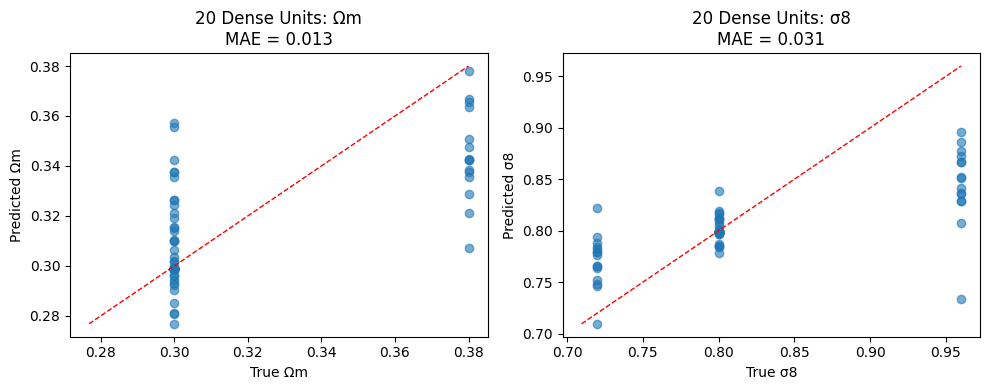

In [89]:
# Plotting predictions on scatter plot

plot_predictions(y_true, y_pred, model_name="20 Dense Units 2 Base Filters Model", save_path="scatter_20_dense.png")

In [90]:
# Evaluating On Test Set ( still in scaled space)
test_loss_20_dense, test_mae_scaled_20_dense= model_20_dense.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_20_dense:.4f}")



Test MAE (scaled): 0.4363


**Perfomance still improving, I havent peaked yet, so im adding more dense units**

### 25 Dense units, 2 Base Filters

In [91]:
# 25 Dense units, 2 Base Filters model
model_25_dense, param_desc_25_dense = build_camels_cnn(
    input_shape=(256,256,1),
    num_outputs=2,
    base_filters=2, # im keeping this constant
    dense_units=25,      # 25 from 20
    dropout=0.5
)
model_25_dense.summary()

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_70 (Conv2D)                   │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_70               │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_70 (LeakyReLU)           │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_71 (Conv2D)                   │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_71               │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_71 (LeakyReLU)           │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_72 (Conv2D)                   │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_72               │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_72 (LeakyReLU)           │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_73 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_73               │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_73 (LeakyReLU)           │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_74 (Conv2D)                   │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_74               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_74 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_75 (Conv2D)                   │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_75               │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 160,189 (625.74 KB)

 Trainable params: 159,681 (623.75 KB)

 Non-trainable params: 508 (1.98 KB)

In [92]:
# Training 25 Dense units, 2 Base Filters model
history_25_dense = train_model(model_25_dense, X_train, y_train, X_val, y_val,sample_weight=sample_weights)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 2.5930 - mae: 1.1475 - val_loss: 1.6811 - val_mae: 0.6410
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.8694 - mae: 0.5529 - val_loss: 1.9891 - val_mae: 0.7616
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5561 - mae: 0.3865 - val_loss: 1.6257 - val_mae: 0.5944
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.5111 - mae: 0.3678 - val_loss: 1.3916 - val_mae: 0.5225
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5195 - mae: 0.3462 - val_loss: 1.1849 - val_mae: 0.4772
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.5238 - mae: 0.3513 - val_loss: 1.1871 - val_mae: 0.4929
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.4294 - mae: 0.3288 - val_loss: 1.1663 - val_mae: 0.4891
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.3631 - mae: 0.2939 - val_loss: 1.0612 - val_mae: 0.4664
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.39

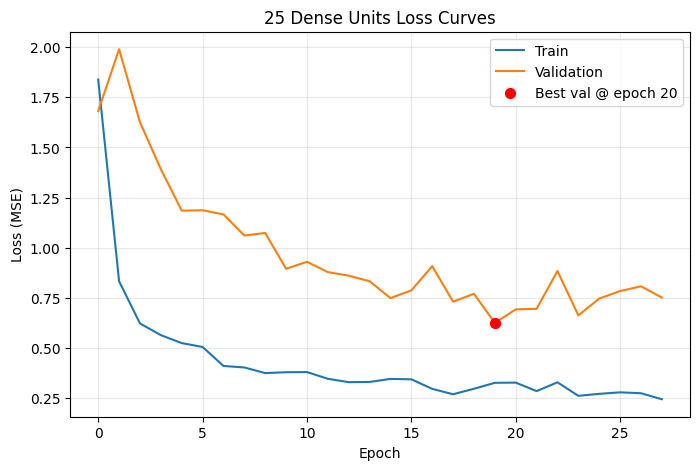

In [93]:
# plotting loss curves
plot_loss_curves(history_25_dense, model_name="25 Dense Units 2 Base Filters Model", save_path="loss_25_dense.png")

In [94]:
# After training, get predictions function
y_true, y_pred = get_predictions(model_25_dense, X_test, scaler, y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step


In [95]:
# saving results
save_model_results(model_25_dense, history_25_dense, X_test, y_test, scaler,
                   model_name="25 Dense Units 2 Base Filters Model", param_desc=param_desc_25_dense)


Ωm: MAE=0.012, MAPE=3.6%, RMSE=0.022, R²=0.453, r=0.679
σ8: MAE=0.028, MAPE=3.3%, RMSE=0.048, R²=0.544, r=0.819
Results saved to model_comparison.csv


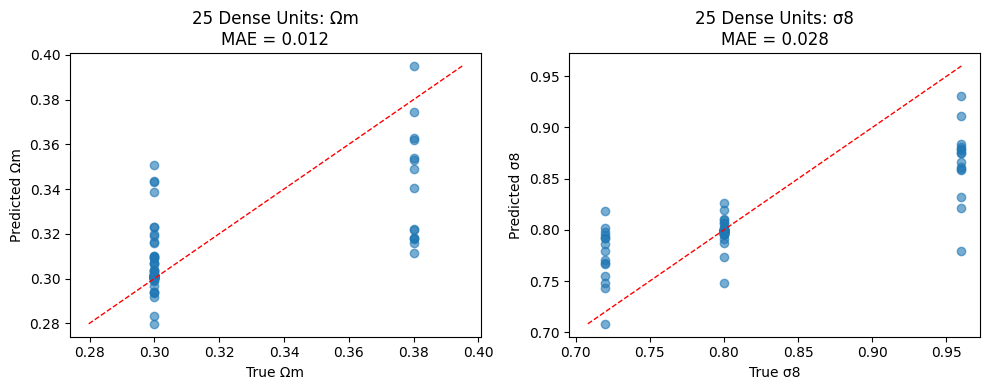

In [96]:
# Plotting predictions on a scatter plot

plot_predictions(y_true, y_pred, model_name="25 Dense Units 2 Base Filters Model", save_path="scatter_25_dense.png")

In [97]:
# Evaluating On Test Set ( still in scaled space)
test_loss_25_dense, test_mae_scaled_25_dense= model_25_dense.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_25_dense:.4f}")



Test MAE (scaled): 0.3975


**Perfomance still improving, going further, no signs of overfitting OR plateaue in perfomance**

### 30 Dense units, 2 Base Filters

In [105]:
# 30 Dense units, 2 Base Filters model
model_30_dense, param_desc_30_dense = build_camels_cnn(
    input_shape=(256,256,1),
    num_outputs=2,
    base_filters=2, # im keeping this constant
    dense_units=30,      # 30 from 25
    dropout=0.5
)
model_30_dense.summary() # 30 Dense units, 2 Base Filters model summary

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_84 (Conv2D)                   │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_84               │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_84 (LeakyReLU)           │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_85 (Conv2D)                   │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_85               │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_85 (LeakyReLU)           │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_86 (Conv2D)                   │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_86               │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_86 (LeakyReLU)           │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_87 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_87               │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_87 (LeakyReLU)           │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_88 (Conv2D)                   │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_88               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_88 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_89 (Conv2D)                   │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_89               │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 160,844 (628.30 KB)

 Trainable params: 160,336 (626.31 KB)

 Non-trainable params: 508 (1.98 KB)

In [106]:
# 30 Dense units, 2 Base Filters model training

history_30_dense = train_model(model_30_dense, X_train, y_train, X_val, y_val,sample_weight=sample_weights)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 1.6545 - mae: 0.9409 - val_loss: 1.6471 - val_mae: 0.6334
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.8020 - mae: 0.5419 - val_loss: 1.7522 - val_mae: 0.7111
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.7005 - mae: 0.4536 - val_loss: 1.2087 - val_mae: 0.5180
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.6110 - mae: 0.4182 - val_loss: 1.0356 - val_mae: 0.4711
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.4829 - mae: 0.3548 - val_loss: 0.9286 - val_mae: 0.4583
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.4264 - mae: 0.3320 - val_loss: 0.8650 - val_mae: 0.4286
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.4076 - mae: 0.3345 - val_loss: 0.8115 - val_mae: 0.4348
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.4420 - mae: 0.3288 - val_loss: 0.7348 - val_mae: 0.4032
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.31

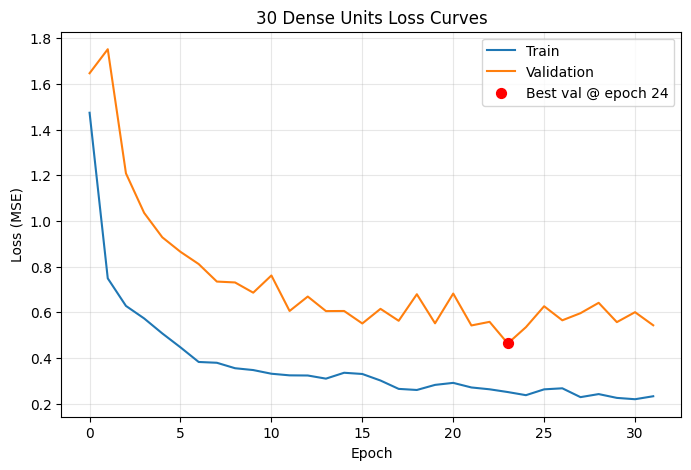

In [107]:
# plotting loss curves 
plot_loss_curves(history_30_dense, model_name="30 Dense Units 2 Base Filters Model", save_path="loss_30_dense.png")

In [108]:
# After training, get predictions function
y_true, y_pred = get_predictions(model_30_dense, X_test, scaler, y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step


In [109]:
# saving model results
save_model_results(model_30_dense, history_30_dense, X_test, y_test, scaler,
                   model_name="30 Dense Units 2 Base Filters Model", param_desc=param_desc_30_dense)


Ωm: MAE=0.010, MAPE=3.0%, RMSE=0.017, R²=0.686, r=0.847
σ8: MAE=0.023, MAPE=2.8%, RMSE=0.039, R²=0.709, r=0.908
Results saved to model_comparison.csv


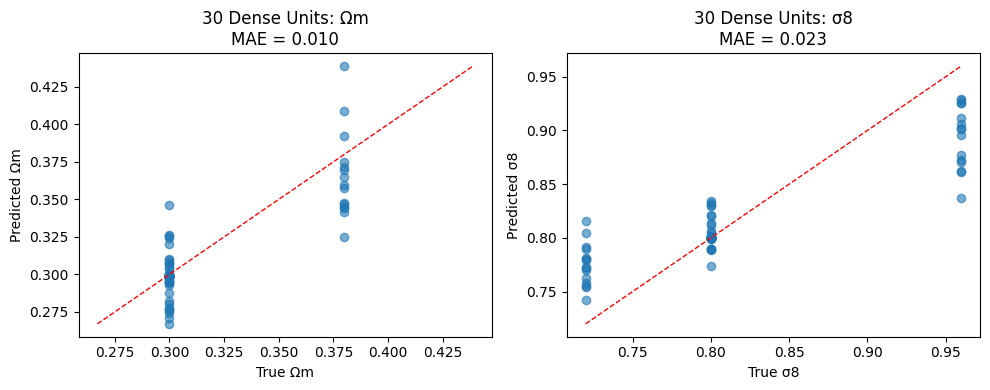

In [110]:
# Plotting prediction scatter plots 

plot_predictions(y_true, y_pred, model_name="30 Dense Units 2 Base Filters Model", save_path="scatter_30_dense.png")

In [111]:
# Evaluating On Test Set ( still in scaled space)
test_loss_30_dense, test_mae_scaled_30_dense= model_30_dense.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE (scaled): {test_mae_scaled_30_dense:.4f}")



Test MAE (scaled): 0.3303


## Hyperparameter Tuning: Manual Grid Search with Group‑Wise Cross‑Validation


So, after manually increasing `dense_units` up to 30 without seeing a clear plateau, I think its time to use a systematic **grid search** over a defined set of hyperparameter values.

Will keep base filters at 2 still, as earlier experiments showed that increasing it prematurely did not improve results.

### Defining the Search Space

I define a dictionary `param_grid` that lists the values to explore for each hyperparameter:

| Parameter | Values Explored |
|-----------|-----------------|
| `dense_units` | 24, 32, 64, 90, 120, 180 |
| `dropout` | 0.20, 0.25, 0.30 |
| `learning_rate` | 1e‑4, 5e‑4, 1e‑3 |
| `batch_size` | 16, 32 |

`base_filters` is held constant at **2**.

Could I go further and expand? Probably yes, but im kinda limited on RAM

### Why a Manual Loop Instead of `GridSearchCV`?

Scikit‑learn's `GridSearchCV` (or `RandomizedSearchCV`) can be a bit heavy with Keras models due to memory management.

Im also confused on how the validation would work because for my problem using Gridsearch or Randomised Search, i need to validate using completely held out param set thats unseen. 

So im writing a manual loop, with probably the same functionality as grid search.

It allows me to : 

- Apply **sample weights** correctly in each fold.
- Clear the Keras backend after every model to prevent memory accumulation. I need this otherwise it will crash
- And also, log intermediate results. 


### Cross‑Validation with `GroupKFold`

I use `GroupKFold` with `n_splits=2` to ensure that all 15 images belonging to the same macrostate stay together in either the training or validation fold. Crucial for my data splitting philosophy outlined up top

This respects the macrostate‑based split already applied to the test set.

### The Search Loop

The following cell unpacks `param_grid` into a list of all possible combinations using `itertools.product`. For each combination:

1. Build a fresh model with the chosen hyperparameters.
2. Train on one fold, validate on the other (with sample weights applied to the training fold).
3. Early stop based on validation loss (patience = 8 epochs).
4. Compute the **MAE** on the validation fold.
5. Clear the Keras session and delete the model to free memory.

The mean MAE across the two folds is recorded for each parameter combination. After evaluating all combinations, the one with the **lowest mean MAE** is selected as the best configuration.

In [38]:
def build_model(base_filters=2, dense_units=24, dropout=0.5, lr=1e-4):
    model, _ = build_camels_cnn(
        input_shape=(256,256,1),
        num_outputs=2,
        base_filters=base_filters,
        dense_units=dense_units,
        dropout=dropout
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

In [40]:
# I already have train_idx (list of image indices belonging to training macrostates)
# and the list train_macro (the macrostate numbers)

# Building groups array: for each image in train_idx, which macrostate does it belong to?
# Since I have 15 images per macrostate in order, I can do:
groups = np.repeat(train_macro, 15)   # shape (795,)

# Computing sample weights (inverse frequency of each macrostate)
unique, counts = np.unique(train_macro, return_counts=True)
freq = counts / len(train_macro)            # frequency of each macrostate
weight_per_macro = 1.0 / freq                # inverse frequency

# Normalising so weights sum to number of samples (optional but helps with learning rate)
weight_per_macro = weight_per_macro / weight_per_macro.mean()

# Mapping each macrostate to its weight and repeat for the 15 images
sample_weights = np.array([weight_per_macro[np.where(unique==m)[0][0]] for m in groups])

In [ ]:
param_grid = {
    'model__base_filters': [2],
    'model__dense_units': [24, 32, 64, 90, 120, 180],
    'model__dropout': [0.20, 0.25, 0.30],          # 3 fixed values replacing uniform()
    'model__lr': [1e-4, 5e-4, 1e-3],
    'batch_size': [16, 32]
}
# ended up not using this
#model = KerasRegressor(model=build_model, verbose=1)
gkf = GroupKFold(n_splits=2)


In [46]:
# Unpacking the hyperparameter grid into a list of all possible combinations
param_keys = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))

results = [] # storing results

# Iterating over each combination of hyperparameters
for param_vals in param_combinations:
    # Creating a dictionary mapping parameter names to their current values
    params = dict(zip(param_keys, param_vals))
    fold_scores = []

    # Performing 2-fold cross-validation with macrostate-respecting splits
    for fold_train_idx, fold_val_idx in gkf.split(X_train, y_train, groups=groups):
        
        # Splitting the data according to the current fold indices
        X_fold_tr, X_fold_val = X_train[fold_train_idx], X_train[fold_val_idx]
        y_fold_tr, y_fold_val = y_train[fold_train_idx], y_train[fold_val_idx]
        
        # Extracting sample weights for the training fold only
        w_fold_tr = sample_weights[fold_train_idx]

        # Separating model-specific hyperparameters from training parameters (for example batch_size)
        model_kwargs = {
            k.replace("model__", ""): v
            for k, v in params.items() if k.startswith("model__")
        }
        batch_size = params["batch_size"]

        # Building a fresh model instance with the current hyperparameters
        m = build_model(**model_kwargs)

        # Training the model on the current fold
        m.fit(
            X_fold_tr, y_fold_tr,
            sample_weight=w_fold_tr,                     # Applying sample weights to beat/or maybe at least reduce class imbalance
            validation_data=(X_fold_val, y_fold_val),    # Monitoring validation performance
            epochs=100,
            batch_size=batch_size,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=8,
                    restore_best_weights=True            # Rolling back to the best epoch
                )
            ],
            verbose=2,
        )

        # Generating predictions on the validation fold and computing MAE
        preds = m.predict(X_fold_val).squeeze()
        score = mean_absolute_error(y_fold_val, preds)
        fold_scores.append(score)

        # Cleaning up the Keras session and deleting the model to free my memory
        keras.backend.clear_session()
        del m
        gc.collect()

    # Calculating the average MAE across the two folds for this hyperparameter combination
    mean_mae = np.mean(fold_scores)
    print(f"{params}  →  MAE: {mean_mae:.4f}")
    results.append({"params": params, "mae": mean_mae})

# Identifying the best hyperparameter combination (lowest mean MAE)
best = min(results, key=lambda x: x["mae"])
print("\nBest params:", best["params"])
print("Best MAE:   ", best["mae"])

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
25/25 - 9s - 364ms/step - loss: 1.7189 - mae: 0.9405 - val_loss: 1.1167 - val_mae: 0.4165
Epoch 2/100
25/25 - 1s - 49ms/step - loss: 1.0724 - mae: 0.6987 - val_loss: 1.1064 - val_mae: 0.4259
Epoch 3/100
25/25 - 1s - 46ms/step - loss: 0.8381 - mae: 0.5977 - val_loss: 1.0931 - val_mae: 0.4451
Epoch 4/100
25/25 - 1s - 45ms/step - loss: 0.6372 - mae: 0.5272 - val_loss: 1.0736 - val_mae: 0.4626
Epoch 5/100
25/25 - 1s - 42ms/step - loss: 0.6160 - mae: 0.5284 - val_loss: 1.0487 - val_mae: 0.4766
Epoch 6/100
25/25 - 1s - 43ms/step - loss: 0.5327 - mae: 0.4896 - val_loss: 1.0146 - val_mae: 0.4820
Epoch 7/100
25/25 - 1s - 50ms/step - loss: 0.4297 - mae: 0.4500 - val_loss: 0.9811 - val_mae: 0.4847
Epoch 8/100
25/25 - 1s - 54ms/step - loss: 0.4333 - mae: 0.4442 - val_loss: 0.9425 - val_mae: 0.4782
Epoch 9/100
25/25 - 1s - 48ms/step - loss: 0.4153 - mae: 0.4340 - val_loss: 0.8999 - val_mae: 0.4691
Epoch 10/100
25/25 - 1s - 44ms/step - loss: 0.3340 - mae: 0.3924 - val_loss: 0.8706 - val_

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
26/26 - 10s - 392ms/step - loss: 1.9205 - mae: 0.9555 - val_loss: 0.8637 - val_mae: 0.3972
Epoch 2/100
26/26 - 1s - 42ms/step - loss: 1.2673 - mae: 0.7482 - val_loss: 0.8703 - val_mae: 0.4269
Epoch 3/100
26/26 - 1s - 42ms/step - loss: 1.1060 - mae: 0.6729 - val_loss: 0.8952 - val_mae: 0.4818
Epoch 4/100
26/26 - 1s - 41ms/step - loss: 0.8707 - mae: 0.6007 - val_loss: 0.9271 - val_mae: 0.5362
Epoch 5/100
26/26 - 1s - 41ms/step - loss: 0.7409 - mae: 0.5569 - val_loss: 0.9546 - val_mae: 0.5742
Epoch 6/100
26/26 - 1s - 43ms/step - loss: 0.7116 - mae: 0.5316 - val_loss: 0.9698 - val_mae: 0.5941
Epoch 7/100
26/26 - 1s - 41ms/step - loss: 0.6231 - mae: 0.5009 - val_loss: 0.9512 - val_mae: 0.5892
Epoch 8/100
26/26 - 1s - 41ms/step - loss: 0.5662 - mae: 0.4642 - val_loss: 0.8968 - val_mae: 0.5560
Epoch 9/100
26/26 - 1s - 42ms/step - loss: 0.5542 - mae: 0.4545 - val_loss: 0.8666 - val_mae: 0.5376
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
{'model__base_filters': 2, 'model__dense_units': 

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


...

Epoch 1/100
26/26 - 24s - 929ms/step - loss: 1.2788 - mae: 0.7633 - val_loss: 0.8480 - val_mae: 0.3996
Epoch 2/100
26/26 - 2s - 69ms/step - loss: 0.6700 - mae: 0.5816 - val_loss: 0.8993 - val_mae: 0.5221
Epoch 3/100
26/26 - 2s - 66ms/step - loss: 0.5062 - mae: 0.5178 - val_loss: 1.0746 - val_mae: 0.6527
Epoch 4/100
26/26 - 2s - 71ms/step - loss: 0.3186 - mae: 0.4208 - val_loss: 1.1199 - val_mae: 0.6820
Epoch 5/100
26/26 - 2s - 64ms/step - loss: 0.2440 - mae: 0.3716 - val_loss: 1.1147 - val_mae: 0.6676
Epoch 6/100
26/26 - 2s - 61ms/step - loss: 0.2097 - mae: 0.3326 - val_loss: 1.0227 - val_mae: 0.6490
Epoch 7/100
26/26 - 2s - 61ms/step - loss: 0.2016 - mae: 0.3267 - val_loss: 0.9077 - val_mae: 0.5712
Epoch 8/100
26/26 - 2s - 61ms/step - loss: 0.1842 - mae: 0.3048 - val_loss: 0.8883 - val_mae: 0.5320
Epoch 9/100
26/26 - 2s - 62ms/step - loss: 0.1427 - mae: 0.2672 - val_loss: 0.7373 - val_mae: 0.4624
Epoch 10/100
26/26 - 2s - 60ms/step - loss: 0.1516 - mae: 0.2670 - val_loss: 0.7206 - val

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
13/13 - 24s - 2s/step - loss: 1.3416 - mae: 0.7921 - val_loss: 1.1152 - val_mae: 0.4565
Epoch 2/100
13/13 - 1s - 109ms/step - loss: 0.6796 - mae: 0.5931 - val_loss: 1.1144 - val_mae: 0.4943
Epoch 3/100
13/13 - 1s - 99ms/step - loss: 0.4883 - mae: 0.5037 - val_loss: 1.1242 - val_mae: 0.5339
Epoch 4/100
13/13 - 1s - 95ms/step - loss: 0.3397 - mae: 0.4354 - val_loss: 1.1420 - val_mae: 0.5816
Epoch 5/100
13/13 - 1s - 93ms/step - loss: 0.2886 - mae: 0.4124 - val_loss: 1.1438 - val_mae: 0.5809
Epoch 6/100
13/13 - 1s - 95ms/step - loss: 0.2654 - mae: 0.3906 - val_loss: 1.1693 - val_mae: 0.6217
Epoch 7/100
13/13 - 1s - 98ms/step - loss: 0.1957 - mae: 0.3468 - val_loss: 1.1479 - val_mae: 0.6065
Epoch 8/100
13/13 - 1s - 94ms/step - loss: 0.1809 - mae: 0.3325 - val_loss: 1.1331 - val_mae: 0.6032
Epoch 9/100
13/13 - 1s - 94ms/step - loss: 0.1619 - mae: 0.3069 - val_loss: 1.1066 - val_mae: 0.5984
Epoch 10/100
13/13 - 1s - 93ms/step - loss: 0.1539 - mae: 0.2950 - val_loss: 1.0889 - val_m

C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
13/13 - 25s - 2s/step - loss: 1.3577 - mae: 0.7822 - val_loss: 0.8685 - val_mae: 0.4018
Epoch 2/100
13/13 - 1s - 107ms/step - loss: 0.7385 - mae: 0.6126 - val_loss: 0.9012 - val_mae: 0.4707
Epoch 3/100
13/13 - 1s - 107ms/step - loss: 0.4341 - mae: 0.4871 - val_loss: 0.9924 - val_mae: 0.5846
Epoch 4/100
13/13 - 1s - 96ms/step - loss: 0.2935 - mae: 0.4156 - val_loss: 1.1519 - val_mae: 0.6788
Epoch 5/100
13/13 - 1s - 96ms/step - loss: 0.2431 - mae: 0.3834 - val_loss: 1.2846 - val_mae: 0.7572
Epoch 6/100
13/13 - 1s - 101ms/step - loss: 0.2342 - mae: 0.3671 - val_loss: 1.4583 - val_mae: 0.8206
Epoch 7/100
13/13 - 1s - 100ms/step - loss: 0.1862 - mae: 0.3245 - val_loss: 1.5628 - val_mae: 0.8625
Epoch 8/100
13/13 - 1s - 96ms/step - loss: 0.1797 - mae: 0.3183 - val_loss: 1.5118 - val_mae: 0.8465
Epoch 9/100
13/13 - 1s - 99ms/step - loss: 0.1558 - mae: 0.2891 - val_loss: 1.5417 - val_mae: 0.8669
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step
{'model__base_filters': 2, 'model__dense_units':

### BEST MODEL FROM HYPERPARAMETER SEARCH

Best params: {'model__base_filters': 2, 'model__dense_units': 120, 'model__dropout': 0.3, 'model__lr': 0.001, 'batch_size': 16}
Best MAE:    0.28154347532199564

In [47]:
# Best hyperparameters (from the search)

best_base_filters = 2
best_dense_units = 120
best_dropout = 0.3
best_lr = 0.001
batch_size = 16

In [48]:
# Building model with best params
best_model, best_params = build_camels_cnn(
    input_shape=(256, 256, 1),
    num_outputs=2,
    base_filters=best_base_filters,
    dense_units=best_dense_units,
    dropout=best_dropout
)


C:\Users\makan\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [49]:
# Compiling it 
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_lr),
    loss='mse',
    metrics=['mae']
)

# best model summary
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 2)         │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 2)         │               8 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128, 128, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 4)           │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 8)           │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 32)            │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 172,634 (674.35 KB)

 Trainable params: 172,126 (672.37 KB)

 Non-trainable params: 508 (1.98 KB)

In [50]:
def train_best_model(model, X_train, y_train, X_val, y_val,
                lr=1e-3, patience=8, epochs=50, batch_size=batch_size, verbose=2,  sample_weight=None):
    """
    Compile and train a Keras model with early stopping.
    
    Returns:
        history: training history object
    """
    # Compiling the model with Adam optimizer and MSE loss for regression
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='mse',
                  metrics=['mae'])
    
    # Setting up early stopping to stop training when validation loss plateaus
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )
    
    # Fitting the model on the full training set (using the best hyperparameters)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose,
        sample_weight=sample_weight
    )
    return history

In [51]:
# Training best model
history_best = train_best_model(best_model, X_train, y_train, X_val, y_val,     sample_weight=sample_weights
)


Epoch 1/50
50/50 - 22s - 443ms/step - loss: 1.3237 - mae: 0.7988 - val_loss: 1.6535 - val_mae: 0.6297
Epoch 2/50
50/50 - 3s - 51ms/step - loss: 0.5794 - mae: 0.5358 - val_loss: 1.9713 - val_mae: 0.7874
Epoch 3/50
50/50 - 3s - 51ms/step - loss: 0.3486 - mae: 0.4244 - val_loss: 1.8757 - val_mae: 0.7503
Epoch 4/50
50/50 - 7s - 146ms/step - loss: 0.2685 - mae: 0.3749 - val_loss: 1.4571 - val_mae: 0.6177
Epoch 5/50
50/50 - 7s - 146ms/step - loss: 0.1947 - mae: 0.3076 - val_loss: 1.0156 - val_mae: 0.4969
Epoch 6/50
50/50 - 3s - 69ms/step - loss: 0.2001 - mae: 0.2870 - val_loss: 0.8813 - val_mae: 0.4687
Epoch 7/50
50/50 - 3s - 58ms/step - loss: 0.1532 - mae: 0.2511 - val_loss: 0.8011 - val_mae: 0.4396
Epoch 8/50
50/50 - 3s - 65ms/step - loss: 0.1273 - mae: 0.2260 - val_loss: 0.6001 - val_mae: 0.3888
Epoch 9/50
50/50 - 3s - 65ms/step - loss: 0.1227 - mae: 0.2159 - val_loss: 0.6119 - val_mae: 0.3986
Epoch 10/50
50/50 - 3s - 56ms/step - loss: 0.1083 - mae: 0.1983 - val_loss: 0.5781 - val_mae: 0.

In [52]:
# Getting predictions plus regression report print out

y_true, y_pred = get_predictions(best_model, X_test, scaler, y_test) # getting predictions

regression_report(y_true, y_pred) # regression report 


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step
Ωm: MAE=0.012, MAPE=3.7%, RMSE=0.023, R²=0.427, r=0.692
σ8: MAE=0.025, MAPE=2.9%, RMSE=0.046, R²=0.583, r=0.851


{'Ωm_MAE': np.float64(0.012274721642335257),
 'Ωm_MAPE': np.float64(3.7127876078408595),
 'Ωm_RMSE': np.float64(0.02257483425290216),
 'Ωm_R2': 0.426673965760745,
 'Ωm_corr': np.float64(0.6923013210791432),
 'σ8_MAE': np.float64(0.02512824334038628),
 'σ8_MAPE': np.float64(2.869117654584073),
 'σ8_RMSE': np.float64(0.04636502902330115),
 'σ8_R2': 0.5830292403667237,
 'σ8_corr': np.float64(0.8511753445950383)}

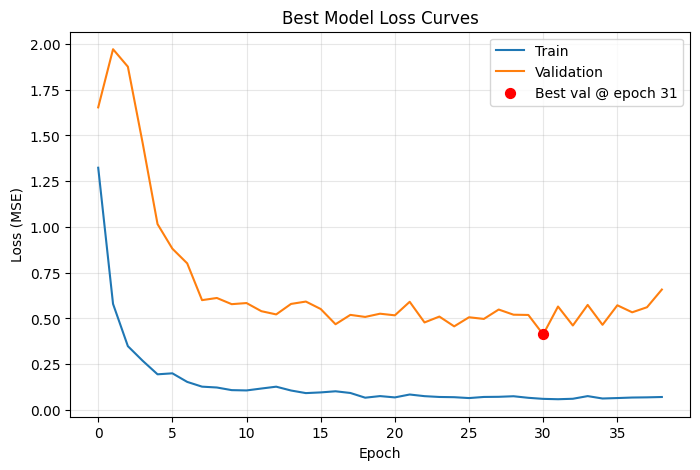

In [53]:
plot_loss_curves(history_best, model_name="Best Model") # plotting loss curves for best model

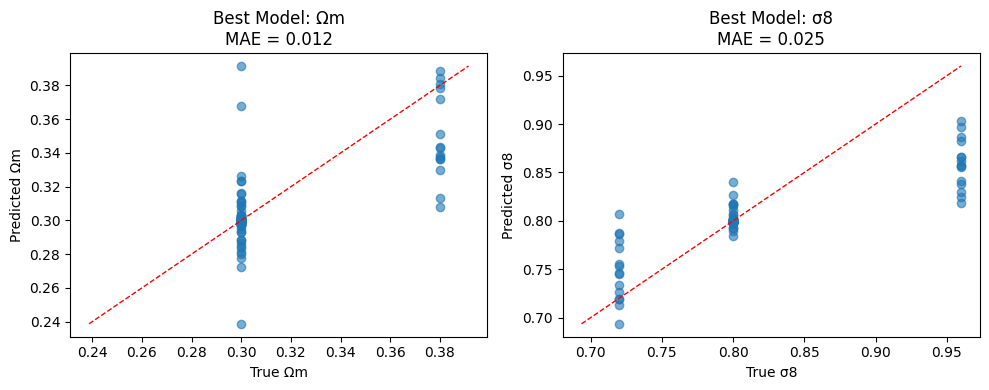

In [55]:
# plotting scatter plot predictions
plot_predictions(y_true, y_pred, model_name="Best Model", save_path="Best Model.png")

Ωm: MAE=0.012, MAPE=3.7%, RMSE=0.023, R²=0.427, r=0.692

σ8: MAE=0.025, MAPE=2.9%, RMSE=0.046, R²=0.583, r=0.851
    
    
**Best model results, decent perfomance across all metrics. Loss curve shows no signs of overfitting or underfitting**

The paper trains on about 15,000 maps per field and predicts 6 parameters total: Ωm, σ8, ASN1, ASN2, AAGN1, AAGN2, with 12 outputs because it predicts mean and variance for each parameter. 

It also uses a much richer setup: 13 fields, plus a multifield input with 11 channels.



My project uses the 1P dataset, with only 990 images per field from 66 parameter combinations × 15 images, and I only care about the 2 cosmological parameters Ωm and σ8.


Therefore, 170k params for best model  is OK. 

# END OF NOTEBOOK


Now that I have my best single field model, with decent MAPE etc compared to CAMELS paper, trained on B but its hyperparameters are representative of other fields, I can do 3 things

1. Apply it on the **multi-field problem** ie stacking all channels and training model on ALL fields. Use the single field architecture as a baseline, then I hypertune it for the multifield problem

2. **Cross field problem** for training a machine learning algortithm on one field and use it to predict the cosmological parameters on other fields

3. Another extension of the multifield which im thinking about, could do it at the end, was thinking of testing what groups of fields, when trained together may beat the multi field. **ie how much info does multifield need really??**